# Прогноз продаж

## Цель

Построить краткосрочный прогноз количества покупок на основе доступной
истории продаж.

История данных короткая: с 04.08.2026 по 10.09.2026, поэтому основной
акцент делаем не на сложности модели, а на честной проверке качества
прогноза.

### Подход

1. Агрегируем покупки по дням.
2. Исследуем временной ряд.
3. Выбираем количество покупок в день как основную целевую метрику.
4. Сравниваем несколько простых baseline-моделей.
5. Проводим backtest на последних днях истории.
6. Выбираем лучший подход по MAE.
7. Строим прогноз на следующие 7 дней.

На данном этапе маркетинговые признаки не используются, поскольку
исторические данные о расходах, placement, channel и creative
отсутствуют или неполны.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
DATA_PATH = Path("../data/raw/base.xlsx")

sales_raw = pd.read_excel(DATA_PATH)

sales_raw.head()

,Номер студента,Сумма,Курс,Время
0,437,8950.0,ML про,2026-08-04 09:08:31
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38
3,443,8475.0,Мат анализ,2026-08-04 10:14:38
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06


In [4]:
sales = sales_raw.rename(
    columns={
        "Номер студента": "student_id",
        "Сумма": "amount",
        "Курс": "course",
        "Время": "timestamp",
    }
).copy()

sales["timestamp"] = pd.to_datetime(sales["timestamp"])
sales["amount"] = pd.to_numeric(sales["amount"], errors="coerce")

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   student_id  795 non-null    int64         
 1   amount      795 non-null    float64       
 2   course      795 non-null    object        
 3   timestamp   795 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 25.0+ KB


### Интерпретация

Одна строка исходного датасета соответствует приобретению курса.
В данных возможны повторные покупки и пакетные предложения, поэтому
на этом этапе под "покупкой" понимаем строку датасета, а не уникального
покупателя или уникальный заказ.

Для временного прогноза нас интересует агрегированное количество таких
покупок по календарным дням.

In [5]:
sales["date"] = sales["timestamp"].dt.normalize()

daily = (
    sales.groupby("date")
    .agg(
        purchases=("course", "size"),
        revenue=("amount", "sum"),
        buyers=("student_id", "nunique"),
    )
    .reset_index()
)

# Восстанавливаем полный календарь.
# Если в какой-то день продаж не было, он должен присутствовать как 0,
# а не исчезать из временного ряда.
full_dates = pd.date_range(
    start=daily["date"].min(),
    end=daily["date"].max(),
    freq="D",
)

daily = (
    daily.set_index("date")
    .reindex(full_dates)
    .rename_axis("date")
    .reset_index()
)

daily[["purchases", "revenue", "buyers"]] = (
    daily[["purchases", "revenue", "buyers"]].fillna(0)
)

daily.head()

,date,purchases,revenue,buyers
0,2026-08-04,9,84130.0,6
1,2026-08-05,8,67110.0,6
2,2026-08-06,8,62445.0,7
3,2026-08-07,6,54995.0,5
4,2026-08-08,49,275015.0,35


In [6]:
print("Начало истории:", daily["date"].min().date())
print("Конец истории:", daily["date"].max().date())
print("Количество дней:", len(daily))
print("Всего покупок:", daily["purchases"].sum())

Начало истории: 2026-08-04
Конец истории: 2026-09-10
Количество дней: 38
Всего покупок: 795


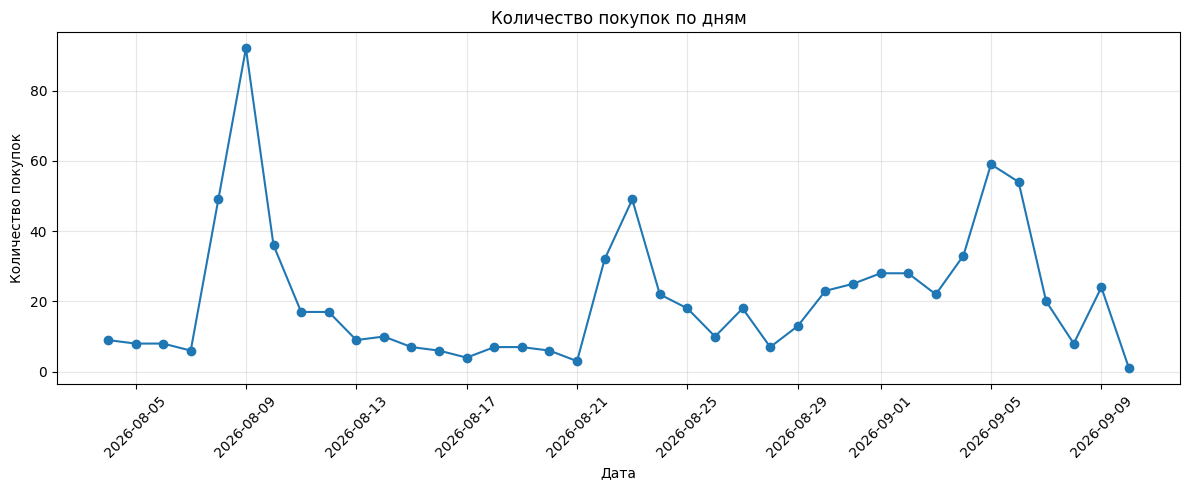

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily["date"],
    daily["purchases"],
    marker="o",
)

plt.title("Количество покупок по дням")
plt.xlabel("Дата")
plt.ylabel("Количество покупок")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

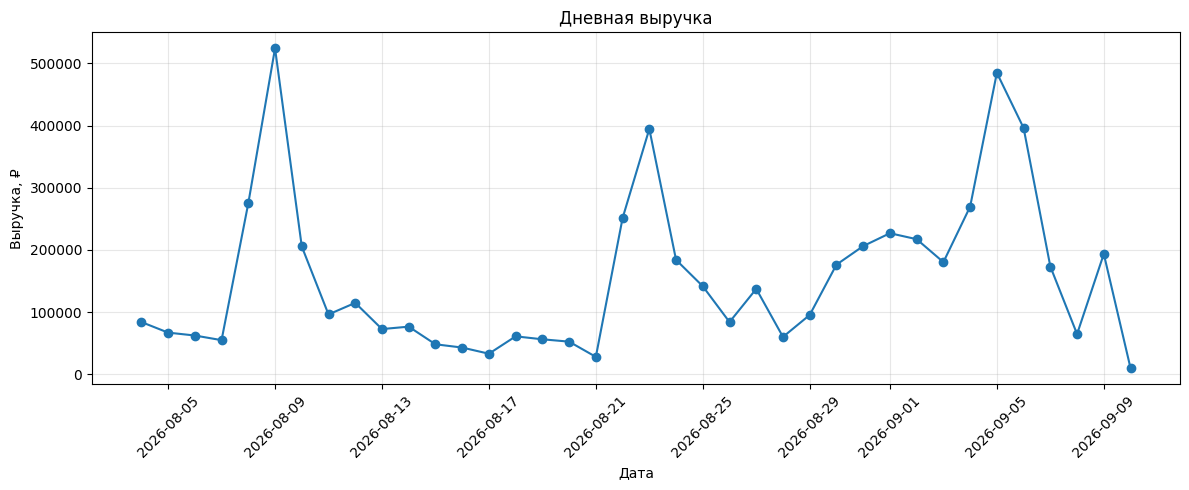

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily["date"],
    daily["revenue"],
    marker="o",
)

plt.title("Дневная выручка")
plt.xlabel("Дата")
plt.ylabel("Выручка, ₽")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Выбор целевой метрики

Основной target — `purchases`, количество покупок в день.

Причины:

- эта метрика напрямую характеризует интенсивность продаж;
- она менее зависит от различий в стоимости отдельных курсов;
- история слишком короткая для сложного многомерного прогноза;
- для бизнеса такой прогноз легко интерпретировать.

Выручка рассматривается как дополнительная метрика, но основной
forecast строится для количества покупок.

первые дни                последние 7 дней
───────────────┬───────────────────────────
    train      │          test
───────────────┴───────────────────────────

In [9]:
TEST_DAYS = 7

train = daily.iloc[:-TEST_DAYS].copy()
test = daily.iloc[-TEST_DAYS:].copy()

print("Train:")
print(train["date"].min().date(), "—", train["date"].max().date())

print("\nTest:")
print(test["date"].min().date(), "—", test["date"].max().date())

Train:
2026-08-04 — 2026-09-03

Test:
2026-09-04 — 2026-09-10


In [10]:
test["pred_naive"] = daily["purchases"].shift(1).loc[test.index]

In [11]:
test["pred_ma7"] = (
    daily["purchases"]
    .shift(1)
    .rolling(7)
    .mean()
    .loc[test.index]
)

In [12]:
test["pred_week_ago"] = (
    daily["purchases"]
    .shift(7)
    .loc[test.index]
)

In [13]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


results = pd.DataFrame(
    {
        "model": [
            "Naive: previous day",
            "7-day moving average",
            "Same weekday last week",
        ],
        "MAE": [
            mae(test["purchases"], test["pred_naive"]),
            mae(test["purchases"], test["pred_ma7"]),
            mae(test["purchases"], test["pred_week_ago"]),
        ],
    }
).sort_values("MAE")

results

,model,MAE
0,Naive: previous day,18.142857
1,7-day moving average,21.469388
2,Same weekday last week,21.857143


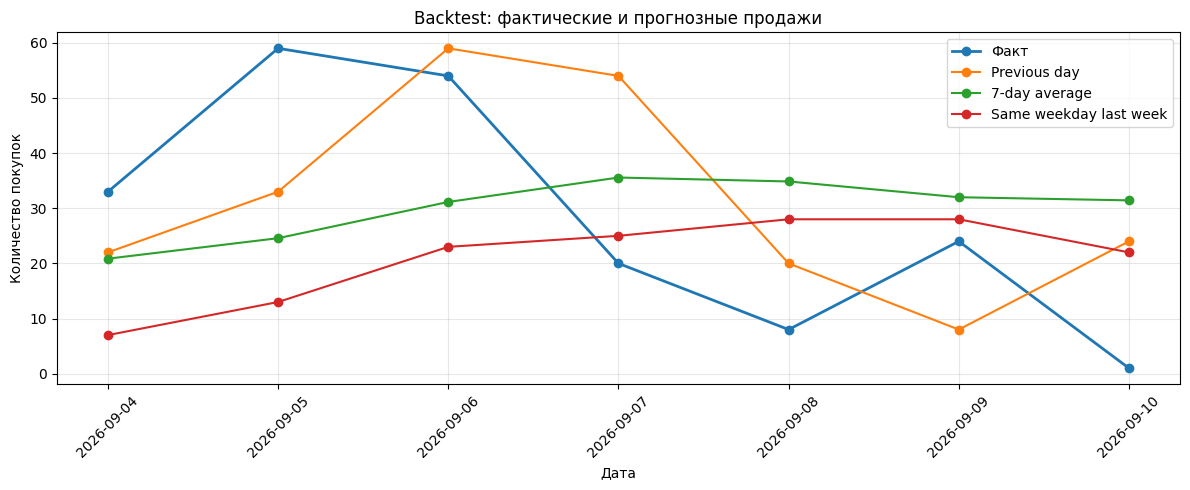

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    test["purchases"],
    marker="o",
    linewidth=2,
    label="Факт",
)

plt.plot(
    test["date"],
    test["pred_naive"],
    marker="o",
    label="Previous day",
)

plt.plot(
    test["date"],
    test["pred_ma7"],
    marker="o",
    label="7-day average",
)

plt.plot(
    test["date"],
    test["pred_week_ago"],
    marker="o",
    label="Same weekday last week",
)

plt.title("Backtest: фактические и прогнозные продажи")
plt.xlabel("Дата")
plt.ylabel("Количество покупок")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Простая regression-модель

После baseline-моделей проверим, может ли простая линейная регрессия
улучшить прогноз.

Используем только признаки, которые известны на момент прогноза:

- `trend` — номер дня в истории;
- `lag_1` — количество покупок вчера;
- `ma_7` — среднее количество покупок за предыдущие 7 дней;
- `weekday` — день недели.

Важно: маркетинговые признаки пока не используются, поскольку
исторически они системно не логировались.

Цель модели — не построить сложный ML, а проверить, может ли
комбинация простых временных признаков обыграть baseline.

In [15]:
# Копируем дневной временной ряд
model_data = daily.copy()

# Номер дня в истории:
# 0, 1, 2, 3, ...
# Позволяет модели учитывать общий тренд
model_data["trend"] = np.arange(len(model_data))

# Продажи предыдущего дня
model_data["lag_1"] = model_data["purchases"].shift(1)

# Средние продажи за ПРЕДЫДУЩИЕ 7 дней.
# shift(1) нужен, чтобы сегодняшние продажи не попали в признаки сегодняшнего дня.
model_data["ma_7"] = (
    model_data["purchases"]
    .shift(1)
    .rolling(7)
    .mean()
)

# День недели:
# 0 = понедельник, ..., 6 = воскресенье
model_data["weekday"] = model_data["date"].dt.dayofweek

model_data.head(10)

,date,purchases,revenue,buyers,trend,lag_1,ma_7,weekday
0,2026-08-04,9,84130.00,6,0,NaN,NaN,1
1,2026-08-05,8,67110.00,6,1,9.0,NaN,2
2,2026-08-06,8,62445.00,7,2,8.0,NaN,3
3,2026-08-07,6,54995.00,5,3,8.0,NaN,4
4,2026-08-08,49,275015.00,35,4,6.0,NaN,5
5,2026-08-09,92,524091.67,68,5,49.0,NaN,6
6,2026-08-10,36,205590.00,29,6,92.0,NaN,0
7,2026-08-11,17,96330.00,12,7,36.0,29.714286,1
8,2026-08-12,17,114930.00,14,8,17.0,30.857143,2
9,2026-08-13,9,72810.00,9,9,17.0,32.142857,3


In [16]:
model_data = model_data.dropna().copy()

model_data[
    ["date", "purchases", "lag_1", "ma_7", "weekday", "trend"]
].head()

,date,purchases,lag_1,ma_7,weekday,trend
7,2026-08-11,17,36.0,29.714286,1,7
8,2026-08-12,17,17.0,30.857143,2,8
9,2026-08-13,9,17.0,32.142857,3,9
10,2026-08-14,10,9.0,32.285714,4,10
11,2026-08-15,7,10.0,32.857143,5,11


In [17]:
model_data = pd.get_dummies(
    model_data,
    columns=["weekday"],
    prefix="weekday",
    dtype=int,
)

model_data.head()

,date,purchases,revenue,buyers,trend,lag_1,ma_7,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
7,2026-08-11,17,96330.0,12,7,36.0,29.714286,0,1,0,0,0,0,0
8,2026-08-12,17,114930.0,14,8,17.0,30.857143,0,0,1,0,0,0,0
9,2026-08-13,9,72810.0,9,9,17.0,32.142857,0,0,0,1,0,0,0
10,2026-08-14,10,76690.0,9,10,9.0,32.285714,0,0,0,0,1,0,0
11,2026-08-15,7,48345.0,5,11,10.0,32.857143,0,0,0,0,0,1,0


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [19]:
# Та же граница тестовой выборки, что использовалась для baseline
test_start_date = test["date"].min()

train_reg = model_data[
    model_data["date"] < test_start_date
].copy()

test_reg = model_data[
    model_data["date"] >= test_start_date
].copy()

print("Train observations:", len(train_reg))
print("Test observations:", len(test_reg))

Train observations: 24
Test observations: 7


In [20]:
feature_cols = [
    col for col in model_data.columns
    if (
        col in ["trend", "lag_1", "ma_7"]
        or col.startswith("weekday_")
    )
]

feature_cols

['trend',
 'lag_1',
 'ma_7',
 'weekday_0',
 'weekday_1',
 'weekday_2',
 'weekday_3',
 'weekday_4',
 'weekday_5',
 'weekday_6']

In [22]:
X_train = train_reg[feature_cols]
y_train = train_reg["purchases"]

X_test = test_reg[feature_cols]
y_test = test_reg["purchases"]

model = LinearRegression()

model.fit(X_train, y_train)

test_reg["pred_regression"] = model.predict(X_test)
test_reg["pred_regression"]

31    16.973723
32    35.612962
33    50.588590
34    30.527148
35    15.377099
36     9.953441
37    19.575881
Name: pred_regression, dtype: float64

In [23]:
test_reg["pred_regression"] = (
    test_reg["pred_regression"]
    .clip(lower=0)
)

In [24]:
regression_mae = mean_absolute_error(
    y_test,
    test_reg["pred_regression"],
)

print(f"Regression MAE: {regression_mae:.2f}")

Regression MAE: 13.34


In [25]:
comparison = pd.concat(
    [
        results,
        pd.DataFrame(
            {
                "model": ["Linear regression"],
                "MAE": [regression_mae],
            }
        ),
    ],
    ignore_index=True,
).sort_values("MAE")

comparison

,model,MAE
3,Linear regression,13.335916
0,Naive: previous day,18.142857
1,7-day moving average,21.469388
2,Same weekday last week,21.857143


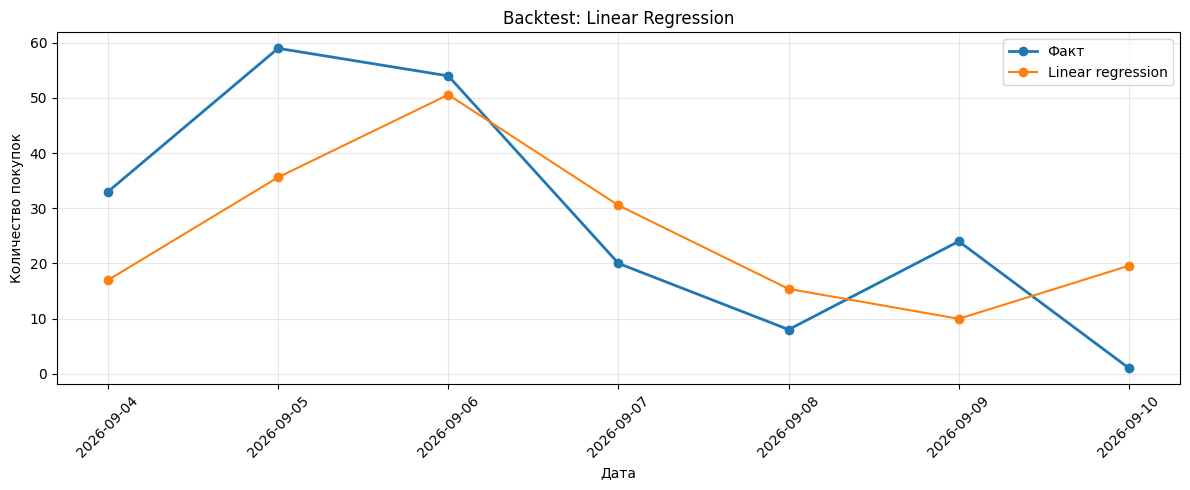

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_reg["date"],
    test_reg["purchases"],
    marker="o",
    linewidth=2,
    label="Факт",
)

plt.plot(
    test_reg["date"],
    test_reg["pred_regression"],
    marker="o",
    label="Linear regression",
)

plt.title("Backtest: Linear Regression")
plt.xlabel("Дата")
plt.ylabel("Количество покупок")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Результаты сравнения моделей

Простая линейная регрессия показала лучший результат на backtest:

- Linear Regression: MAE = 13.34
- Naive Previous Day: MAE = 18.14
- 7-day Moving Average: MAE = 21.47
- Same Weekday Last Week: MAE = 21.86

Таким образом, линейная регрессия снижает среднюю абсолютную ошибку
примерно на 26.5% относительно лучшего baseline.

Модель использует только исторически доступные признаки:
продажи предыдущего дня, среднее за предыдущие 7 дней,
день недели и временной тренд.

Несмотря на улучшение относительно baseline, ошибка остаётся высокой,
а ряд содержит сильные краткосрочные всплески и провалы.
Это ограничивает надёжность прогноза и указывает на недостаток
объясняющих факторов в текущих данных.

## Финальный прогноз на 7 дней

По результатам backtest лучшей моделью оказалась линейная регрессия.

Для финального прогноза модель переобучается на всей доступной истории
продаж до 10.09.2026.

Прогноз строится рекурсивно:

1. прогнозируем следующий день;
2. используем полученный прогноз как `lag_1` для следующего дня;
3. пересчитываем среднее за последние 7 дней;
4. повторяем процесс для всего горизонта в 7 дней.

Таким образом, при прогнозировании будущей недели модель не использует
фактические значения из будущего.

Прогноз отражает ожидаемый уровень продаж при продолжении исторической
динамики и не учитывает неизвестные будущие маркетинговые активности.

In [27]:
# Используем все доступные наблюдения после формирования lag-признаков
X_full = model_data[feature_cols]
y_full = model_data["purchases"]

final_model = LinearRegression()

final_model.fit(X_full, y_full)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.33, 0.67,-0.47,...,-1.73,13.23, 8.6 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['trend','lag_1','ma_7',...,'weekday_4','weekday_5','weekday_6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.64
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [28]:
FORECAST_DAYS = 7

# История продаж до последнего известного дня.
# В этот список далее будем добавлять уже прогнозные значения.
history_values = daily["purchases"].astype(float).tolist()

# Следующий день после последнего наблюдаемого
last_date = daily["date"].max()

forecast_rows = []

for step in range(FORECAST_DAYS):
    
    # Дата, которую прогнозируем
    future_date = last_date + pd.Timedelta(days=step + 1)
    
    # Продажи предыдущего дня.
    # Для первого прогноза это реальный последний день,
    # далее — уже предыдущий прогноз модели.
    lag_1 = history_values[-1]
    
    # Среднее за последние 7 доступных значений.
    # На будущих шагах здесь будут присутствовать и прогнозные значения.
    ma_7 = np.mean(history_values[-7:])
    
    # Продолжаем временной тренд
    trend = len(daily) + step
    
    # День недели:
    # 0 = понедельник, ..., 6 = воскресенье
    weekday = future_date.dayofweek
    
    # Создаём строку с теми же признаками,
    # которые использовались при обучении модели
    row = {
        "trend": trend,
        "lag_1": lag_1,
        "ma_7": ma_7,
    }
    
    # Сначала выставляем все weekday dummy в 0
    for col in feature_cols:
        if col.startswith("weekday_"):
            row[col] = 0
    
    # Для нужного дня недели ставим 1
    weekday_col = f"weekday_{weekday}"
    
    if weekday_col in row:
        row[weekday_col] = 1
    
    # DataFrame обязательно создаём в том же порядке признаков,
    # что использовался при обучении
    X_future = pd.DataFrame(
        [row],
        columns=feature_cols,
    )
    
    # Получаем прогноз
    prediction = final_model.predict(X_future)[0]
    
    # Количество покупок не может быть отрицательным
    prediction = max(prediction, 0)
    
    forecast_rows.append(
        {
            "date": future_date,
            "predicted_purchases": prediction,
        }
    )
    
    # Добавляем прогноз в историю,
    # чтобы использовать его для следующего дня
    history_values.append(prediction)

In [29]:
forecast = pd.DataFrame(forecast_rows)

forecast

,date,predicted_purchases
0,2026-09-11,6.650262
1,2026-09-12,27.506529
2,2026-09-13,39.311220
3,2026-09-14,28.808548
4,2026-09-15,28.617131
5,2026-09-16,32.577735
6,2026-09-17,27.799265


In [30]:
forecast["predicted_purchases_rounded"] = (
    forecast["predicted_purchases"]
    .round()
    .astype(int)
)

forecast

,date,predicted_purchases,predicted_purchases_rounded
0,2026-09-11,6.650262,7
1,2026-09-12,27.506529,28
2,2026-09-13,39.311220,39
3,2026-09-14,28.808548,29
4,2026-09-15,28.617131,29
5,2026-09-16,32.577735,33
6,2026-09-17,27.799265,28


In [31]:
total_forecast = forecast["predicted_purchases"].sum()
avg_forecast = forecast["predicted_purchases"].mean()

print(
    f"Прогноз покупок за следующие 7 дней: "
    f"{total_forecast:.0f}"
)

print(
    f"Среднее количество покупок в день: "
    f"{avg_forecast:.1f}"
)

Прогноз покупок за следующие 7 дней: 191
Среднее количество покупок в день: 27.3


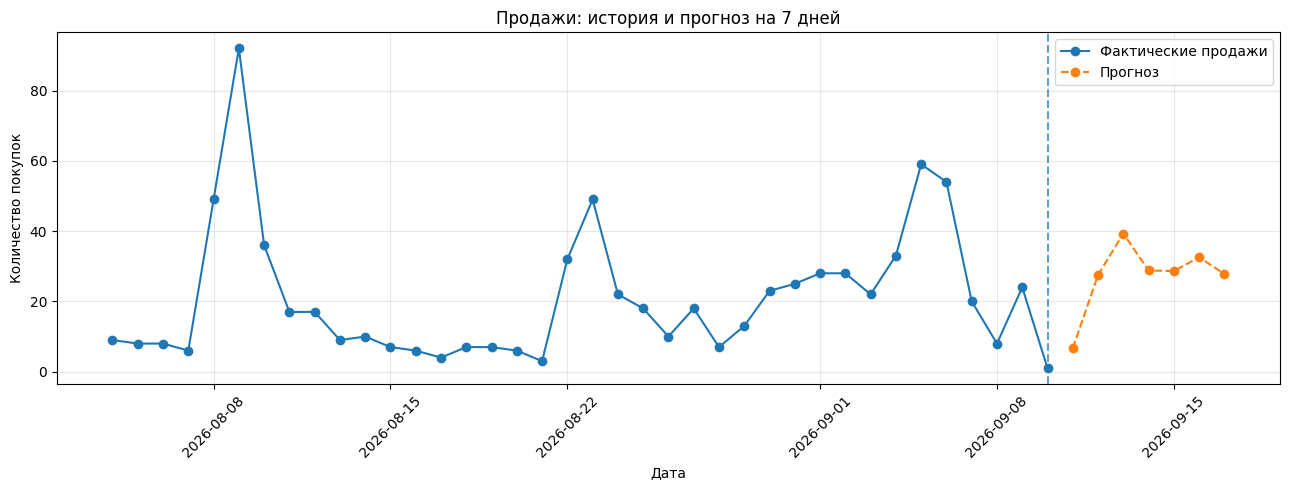

In [32]:
plt.figure(figsize=(13, 5))

# Реальная история
plt.plot(
    daily["date"],
    daily["purchases"],
    marker="o",
    label="Фактические продажи",
)

# Прогноз
plt.plot(
    forecast["date"],
    forecast["predicted_purchases"],
    marker="o",
    linestyle="--",
    label="Прогноз",
)

plt.axvline(
    daily["date"].max(),
    linestyle="--",
    alpha=0.7,
)

plt.title("Продажи: история и прогноз на 7 дней")
plt.xlabel("Дата")
plt.ylabel("Количество покупок")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Ограничения прогноза

Прогноз следует интерпретировать как базовый сценарий продолжения
наблюдаемой динамики продаж.

Backtest показал, что даже лучшая модель имеет MAE около 13.3 покупки
в день, поэтому точечные значения прогноза обладают высокой
неопределённостью.

Основное ограничение — короткая история и отсутствие системно
собранных маркетинговых признаков. Модель не знает, будут ли в
прогнозируемые дни новые рекламные размещения, скидки, запуски или
другие активности.

Поэтому текущий прогноз отвечает на вопрос:

**«Какого уровня продаж можно ожидать, если ориентироваться только
на доступную историческую динамику?»**

Он не отвечает на вопрос:

**«Сколько продаж даст новая рекламная кампания?»**

### Итог прогноза

После сравнения нескольких baseline-подходов лучшей моделью оказалась
линейная регрессия с MAE = 13.34 покупки в день.

Модель была переобучена на всей доступной истории и использована
для рекурсивного прогноза на следующие 7 дней.

Полученный прогноз:

- ожидаемое количество покупок за неделю: ≈ 191;
- среднее количество покупок в день: ≈ 27;
- дневной прогноз варьируется примерно от 7 до 39 покупок.

Однако прогноз обладает высокой неопределённостью.
Средняя ошибка модели на backtest составляет около 13 покупок в день.

Модель использует только временную динамику продаж:
продажи предыдущего дня, среднее за предыдущие 7 дней,
день недели и временной тренд.

Она не учитывает будущие рекламные кампании, скидки, запуски,
размещения и рекламный бюджет, поскольку эти признаки исторически
не собирались системно.

Поэтому прогноз следует рассматривать как baseline-сценарий,
а не как точную оценку будущего спроса.

# Прогноз после внедрения Measurement System

## 1. Что изменится

Текущий прогноз строится почти исключительно на истории продаж:

past sales
+ lag_1
+ rolling mean
+ weekday
+ trend

→ forecast

После внедрения Measurement System появится регулярная история
маркетинговых активностей и пользовательских действий.

Это позволит построить модель, которая учитывает не только прошлые
продажи, но и маркетинговый план.

Целевая переменная первой версии:

**количество успешно оплаченных заказов в день.**

Гранулярность первой версии:

**date × product_line (START / PRO)**

При недостаточном количестве данных прогноз можно временно строить
на уровне всего бизнеса.

---

## 2. Из каких таблиц берутся данные

Measurement System хранит:

campaigns
→ placements
→ creatives
→ tracking_links
→ bot_events
→ leads
→ orders
→ payments

Для прогнозирования эти таблицы объединяются в отдельную
forecast mart — таблицу, где одна строка соответствует одному дню.

### Целевая метрика

Из `payments` и `orders`:

- `paid_orders` — количество уникальных оплаченных order_id;
- `revenue` — сумма успешных платежей.

Используются только:

payment.status = "succeeded"

---

## 3. Признаки, известные до запуска

Это признаки, которые можно использовать для настоящего forecast,
потому что компания знает их заранее.

| Признак | Откуда берём | Что означает |
|---|---|---|
| planned_spend | placements.cost | сколько запланировано потратить в этот день |
| placements_count | placements | число запланированных рекламных размещений |
| external_placements | placements.placement_type | число внешних размещений |
| own_placements | placements.placement_type | число публикаций в собственном канале |
| unique_channels | placements.channel_id | число рекламных каналов |
| campaign_active | campaigns | активна ли кампания |
| product_line | campaigns.product_line | START / PRO |
| activity_type | creatives.activity_type | sale_post / discount / launch / native |
| creative_format | creatives.format | text / image / video |
| weekday | calendar | день недели |
| lag_1_orders | historical orders | продажи предыдущего дня |
| rolling_7_orders | historical orders | средние продажи за предыдущие 7 дней |

Например, если на 20 сентября заранее запланированы:

planned_spend = 80 000
placements_count = 4
external_placements = 3
own_placements = 1
activity_type = launch
product_line = PRO

то именно эти значения передаются модели для прогноза продаж
на 20 сентября.

Мы не придумываем эти данные: они появляются в Marketing Registry
ещё до публикации рекламы.

---

## 4. Как строится обучающий датасет

После накопления истории создаётся таблица примерно такого вида:

| date | paid_orders | lag_1 | rolling_7 | planned_spend | placements | external | own | launch | discount | product_line |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---|
| 01.10 | 24 | 19 | 21.4 | 0 | 0 | 0 | 0 | 0 | 0 | START |
| 02.10 | 31 | 24 | 22.8 | 25000 | 1 | 1 | 0 | 0 | 0 | START |
| 03.10 | 48 | 31 | 25.7 | 60000 | 3 | 2 | 1 | 1 | 0 | START |
| ... | ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |

Каждая строка показывает:

1. какой маркетинговый план был известен на этот день;
2. сколько покупок реально произошло;
3. что происходило с продажами в предыдущие дни.

На такой истории модель сможет обучаться связи:

marketing plan + past sales
→ future paid orders

---

## 5. Какую модель планируем использовать

Текущая Linear Regression остаётся baseline.

После накопления достаточного количества данных мы сравниваем:

Linear Regression
vs
CatBoost с маркетинговыми признаками

CatBoost рассматривается как основной кандидат, потому что будущий
датасет будет содержать:

- числовые признаки: spend, количество placements, лаги продаж;
- категориальные признаки: channel, product_line, creative type;
- нелинейные взаимодействия между маркетинговыми признаками.

Например, влияние `planned_spend` может зависеть одновременно от:

planned_spend
+ channel
+ launch
+ creative_type
+ product_line

CatBoost умеет моделировать такие зависимости без ручного задания
формулы.

Модель используется только если она на честном backtest устойчиво
показывает меньшую ошибку, чем baseline.

---

## 6. Как проверяем качество модели

Используем только time-based backtest.

Нельзя случайно перемешивать прошлое и будущее.

Пример:

Train:
01.10–31.10

Test:
01.11–07.11

Затем окно сдвигается:

Train:
01.10–07.11

Test:
08.11–14.11

Основная метрика:

MAE — средняя абсолютная ошибка количества покупок в день.

Например:

Baseline MAE = 18
Linear Regression MAE = 13
CatBoost MAE = 9

Только в таком случае можно утверждать, что добавление
маркетинговых данных действительно улучшило прогноз.

---

## 7. Роль Telegram-бота

Telegram-бот особенно полезен после начала кампании.

Он фиксирует:

- `bot_start`;
- уникального обезличенного `user_id`;
- `tracking_id`;
- выбранный курс;
- создание lead;
- начало checkout;
- order_id.

Поэтому во время уже запущенной кампании появляются дополнительные
фактические признаки:

bot_starts
unique_users
course_selected
leads
checkout_started

Они строятся из `bot_events` и `leads`.

---

## 8. Forecast и Nowcast — разные модели

### Forecast до запуска

Используем только то, что известно заранее:

past sales
+ planned_spend
+ placements
+ channels
+ campaign
+ activity_type
+ calendar
→ predicted orders

Например:

Маркетинговый план на следующую неделю
→ модель
→ ожидаем 160 оплаченных заказов

### Nowcast после начала кампании

Когда реклама уже работает, можно добавить фактическую реакцию пользователей:

planned marketing
+ bot_starts
+ leads
+ checkout_started
+ past sales
→ updated forecast

Например:

До запуска:
ожидали 160 заказов.

Через два дня:
получили 500 bot_start,
140 leads,
70 checkout_started.

→ пересчитываем прогноз.

Таким образом Telegram-бот позволяет обновлять ожидания во время кампании.

---

## 9. Data leakage

Для forecast нельзя использовать события, которые ещё не произошли.

Например, при прогнозе продаж на завтра нельзя заранее использовать:

- завтрашние bot_start;
- завтрашние leads;
- завтрашние checkout;
- завтрашние payments.

Эти данные появляются только после начала дня.

Поэтому:

**Forecast**
использует только marketing plan + прошлую историю.

**Nowcast**
может использовать уже наблюдаемые bot events текущей кампании.

---

## 10. Как прогноз будет работать для бизнеса

### До кампании

Маркетолог создаёт:

campaign
→ placements
→ creatives
→ tracking links

В системе уже известны:

- бюджет;
- количество размещений;
- каналы;
- даты публикаций;
- типы креативов;
- продукт.

Из этих данных автоматически формируются будущие строки forecast mart.

Модель оценивает ожидаемое количество продаж.

### После запуска

Пользователи переходят:

tracking link
→ Telegram bot

Начинают появляться:

bot_start
→ course_selected
→ lead
→ checkout
→ payment

По мере появления этих событий nowcast обновляется.

После завершения кампании фактические результаты добавляются
в исторический датасет и используются при следующем обучении модели.

---

## 11. Важное ограничение

Сразу после запуска Measurement System CatBoost обучить нельзя.

Сначала необходимо накопить реальную историю:

marketing plan
+ bot events
+ orders
+ payments

Только после накопления достаточного количества кампаний можно
проверить, действительно ли маркетинговые признаки улучшают прогноз.

Поэтому развитие системы выглядит так:

Этап 1:
текущая Linear Regression по истории продаж

↓

Этап 2:
Measurement System начинает собирать данные

↓

Этап 3:
формируется forecast mart

↓

Этап 4:
Linear Regression сравнивается с CatBoost

↓

Этап 5:
лучшая модель используется для forecast

↓

Этап 6:
bot events используются для nowcast во время кампании